In [121]:
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.ticker import FuncFormatter

import os
while not os.path.isdir('.git'):
    os.chdir('../..')

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

fig_width = 11.27

mpl.rcParams["axes.labelsize"] = 9
mpl.rcParams["xtick.labelsize"] = 9
mpl.rcParams["ytick.labelsize"] = 9
mpl.rcParams["legend.fontsize"] = 9
mpl.rcParams["axes.titlesize"] = 9

In [122]:
test_stimulus_1 = 100
test_stimulus_2 = 2500

ltp_frequency = 50
ltp_start = 1000
ltp_duration = 1000

time_before = 50
time_after = 100

In [123]:
idxs = np.arange(0, 20)

# Figure Results 3

In [124]:
def read_weights(carrier = 1000, offset = 5, strength = 0.9, initial_weight = 0.1):
    if carrier is None:
        filename = f"noTI_{initial_weight}"
    else:
        filename = f"{carrier}_{offset}_{strength}_{initial_weight}"
    
    synapses = [f"Synapse{i}" for i in range(10)]
    weights = []
    time = []
    for idx in idxs:
        weights_idx = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/{filename}/synapse_weights.csv", index_col = 0)
    
        for synapse in synapses:
            weights.append(weights_idx[synapse])
        
        time = weights_idx.Time
    
    weights = np.vstack(weights)
    
    return time, weights

In [125]:
initial_weight = 0.1
carrier = 1000

time_no_ti, weights_no_ti = read_weights(carrier = None, initial_weight = initial_weight)
time_5, weights_5 = read_weights(carrier = carrier, offset = 5, strength = 0.9, initial_weight = initial_weight)
time_130, weights_130 = read_weights(carrier = carrier, offset = 130, strength = 0.9, initial_weight = initial_weight)
time_0, weights_0 = read_weights(carrier = carrier, offset = 0, strength = 0.1, initial_weight = initial_weight)

In [126]:
final_weights = {
    "No TI": [],
    "5 Hz TI": [],
    "130 Hz TI": [],
    "0 Hz TI": []
}

for condition, weight, time in zip(
        final_weights.keys(),
        [weights_no_ti, weights_5, weights_130, weights_0],
        [time_no_ti, time_5, time_130, time_0]
):
    time_idx = np.where(time > ltp_start + ltp_duration + 100)[0][0]
    final_weights[condition] = weight[:, time_idx]

In [127]:
def match_array_size(*arrays):
    min_len = min(arr.shape[0] for arr in arrays)
    return [arr[:min_len] for arr in arrays]

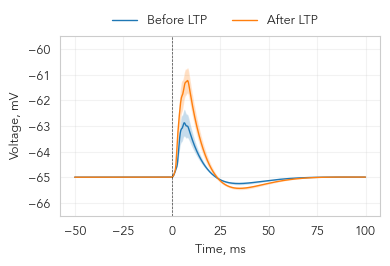

In [128]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (4, 2.5))
ax = axs

epsp_before = []
epsp_after = []

time = []

for idx in idxs:
    voltage = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/noTI_0.1/voltage.csv")

    time_epsp_before = np.logical_and(voltage.Time > test_stimulus_1 - time_before, voltage.Time < test_stimulus_1 + time_after)
    epsp_before_idx = np.array(voltage.Voltage[time_epsp_before].tolist())
    epsp_before.append(epsp_before_idx)

    time_epsp_after = np.logical_and(voltage.Time > test_stimulus_2 - time_before, voltage.Time < test_stimulus_2 + time_after)
    epsp_after_idx = np.array(voltage.Voltage[time_epsp_after].tolist())
    epsp_after.append(epsp_after_idx)

    time = np.array((voltage.Time[time_epsp_before] - test_stimulus_1).tolist())
    time, epsp_before_idx, epsp_after_idx = match_array_size(time, epsp_before_idx, epsp_after_idx)

epsp_before = np.array(epsp_before).T
epsp_after = np.array(epsp_after).T

time, epsp_before, epsp_after = match_array_size(time, epsp_before, epsp_after)

mean = epsp_before.mean(axis = 1)
error = epsp_before.std(axis = 1)  / np.sqrt(epsp_before.shape[1])

plt.plot(
    time,
    mean,
    linewidth = 1,
    label = "Before LTP"
)
plt.fill_between(
    time, mean - error, mean + error,
    alpha = 0.25
)

mean = epsp_after.mean(axis = 1)
error = epsp_after.std(axis = 1) / np.sqrt(epsp_after.shape[1])

ax.plot(
    time,
    mean,
    linewidth = 1,
    label = "After LTP"
)
ax.fill_between(
    time, mean - error, mean + error,
    alpha = 0.25
)

ax.set_xlabel("Time, ms")
ax.set_ylabel("Voltage, mV")
ax.set_ylim(-66.5, -59.5)
ax.axvline(0, linewidth = 0.5, linestyle = "--", color = "black", alpha = 0.75)
ax.grid(True, alpha = 0.25)

fig.legend(loc = "upper center", ncol = 2, frameon = False, bbox_to_anchor = (0.55, 1.07))
fig.tight_layout()
plt.show()

Mean conductance: 67 pS
STD: 14 pS


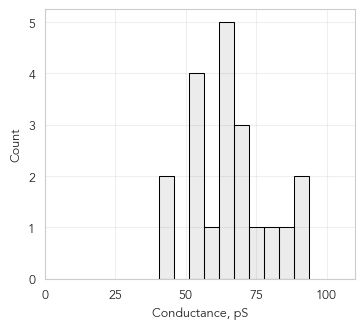

In [129]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (4, 3.5))
ax = axs

final_conductance = []
for idx in idxs:
    results = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance_results.csv")
    final_conductance.append(results.iloc[-1].Conductance)

ax.hist(np.array(final_conductance) * 1000_000, bins = 10, orientation = "vertical", facecolor = (0, 0, 0, 0.075), edgecolor = "black", linewidth = 0.75)
ax.set_xlabel(r"Conductance, pS")
ax.set_ylabel("Count")
ax.set_xlim(0, 110)
ax.set_xticks(range(0, 125, 25))
ax.grid(True, alpha = 0.3)

print(f"Mean conductance: {round(np.mean(np.array(final_conductance) * 1000_000))} pS")
print(f"STD: {round(np.std(np.array(final_conductance) * 1000_000))} pS")

In [130]:
colors = {
    "No TI": "tab:blue",
    "0 Hz TI": "tab:red",
    "5 Hz TI": "tab:orange",
    "130 Hz TI": "tab:green"
}

In [131]:
def pad_edges(data, pad_width):
    return np.pad(data, pad_width, mode="edge")

In [132]:
def smooth_data(data, window_size=10):
    dt = np.convolve(data, np.ones(window_size)/window_size, mode="valid")
    len_diff = len(data) - len(dt)
    
    return pad_edges(dt, int(len_diff / 2))

In [133]:
def plot_weights(weights, time, label, color, ax):
    mean = smooth_data(weights.mean(axis = 0), window_size = 1000)
    error = weights.std(axis = 0) / np.sqrt(weights.shape[0])
    error = error[:-1]

    ax.plot(
        time[:-1],
        mean,
        linewidth = 1,
        label = label,
        color = color
    )

    ax.fill_between(
        time[:-1], mean - error, mean + error,
        alpha = 0.15,
        color = color
    )

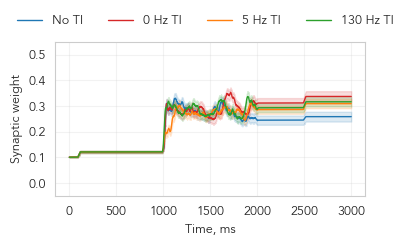

In [134]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (4, 2))
ax = axs

plot_weights(weights_no_ti, time_no_ti, label = "No TI", color = colors["No TI"], ax = ax)
plot_weights(weights_0, time_0, label = "0 Hz TI", color = colors["0 Hz TI"], ax = ax)
plot_weights(weights_5, time_5, label = "5 Hz TI", color = colors["5 Hz TI"], ax = ax)
plot_weights(weights_130, time_130, label = "130 Hz TI", color = colors["130 Hz TI"], ax = ax)

ax.set_ylim(-0.05, 0.55)
ax.set_ylabel("Synaptic weight")
ax.set_yticks(np.arange(0, 0.6, 0.1))

ax.set_xlabel("Time, ms")

ax.grid(alpha = 0.25)
fig.legend(loc = "upper center", ncol = 4, frameon = False, bbox_to_anchor = (0.5, 1.07))

plt.show()

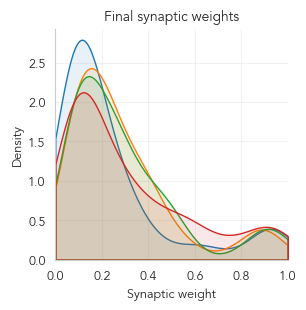

In [135]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (3, 3))
ax = axs

for condition in final_weights.keys():
    sns.kdeplot(
        final_weights[condition],
        bw_adjust = 1,
        ax = ax,
        clip = (0, 1),
        label = condition,
        fill = True,
        alpha = 0.1
    )

ax.set_xlim(0, 1)
ax.set_xlabel("Synaptic weight")

ax.grid(alpha = 0.25)
sns.despine(top = True, right = True)

ax.set_title("Final synaptic weights", fontsize = 10)

plt.show()

EPSP before: 2.12
STD: 2.35
EPSP after: 3.76
STD: 2.22


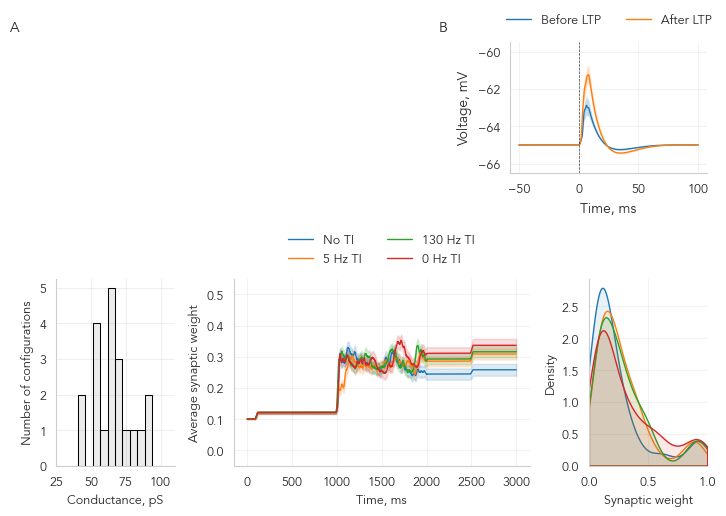

In [136]:
fig = plt.figure(figsize = (8.4, 5.5))

outer_gs = gridspec.GridSpec(3, 1, height_ratios = [0.7, 0.3, 1])

# A panel - neuron with synapses marked
# B panel - EPSP

inner_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec = outer_gs[0], width_ratios = [2, 1])
ax = fig.add_subplot(inner_gs[0, 1])

epsp_before = []
epsp_after = []

time = []

for idx in idxs:
    voltage = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/noTI_0.1/voltage.csv")

    time_epsp_before = np.logical_and(voltage.Time > test_stimulus_1 - time_before, voltage.Time < test_stimulus_1 + time_after)
    epsp_before_idx = np.array(voltage.Voltage[time_epsp_before].tolist())
    epsp_before.append(epsp_before_idx)

    time_epsp_after = np.logical_and(voltage.Time > test_stimulus_2 - time_before, voltage.Time < test_stimulus_2 + time_after)
    epsp_after_idx = np.array(voltage.Voltage[time_epsp_after].tolist())
    epsp_after.append(epsp_after_idx)

    time = np.array((voltage.Time[time_epsp_before] - test_stimulus_1).tolist())
    time, epsp_before_idx, epsp_after_idx = match_array_size(time, epsp_before_idx, epsp_after_idx)

epsp_before = np.array(epsp_before).T
epsp_after = np.array(epsp_after).T

time, epsp_before, epsp_after = match_array_size(time, epsp_before, epsp_after)

mean = epsp_before.mean(axis = 1)
error = epsp_before.std(axis = 1)  / np.sqrt(epsp_before.shape[1])

max_at = np.argmax(mean)
std = epsp_before.std(axis = 1)
print(f"EPSP before: {round(mean[max_at] - mean[0], 2)}")
print(f"STD: {round(std[max_at], 2)}")

plt.plot(
    time,
    mean,
    linewidth = 1,
    label = "Before LTP"
)
plt.fill_between(
    time, mean - error, mean + error,
    alpha = 0.25
)

mean = epsp_after.mean(axis = 1)
error = epsp_after.std(axis = 1) / np.sqrt(epsp_after.shape[1])

max_at = np.argmax(mean)
std = epsp_after.std(axis = 1)
print(f"EPSP after: {round(mean[max_at] - mean[0], 2)}")
print(f"STD: {round(std[max_at], 2)}")

ax.plot(
    time,
    mean,
    linewidth = 1,
    label = "After LTP"
)
ax.fill_between(
    time, mean - error, mean + error,
    alpha = 0.25
)

ax.set_xlabel("Time, ms", fontsize = 10)
ax.set_ylabel("Voltage, mV", fontsize = 10)
ax.set_ylim(-66.5, -59.5)
ax.axvline(0, linewidth = 0.5, linestyle = "--", color = "black", alpha = 0.75)
ax.grid(True, alpha = 0.25)

ax.legend(loc = "upper center", frameon = False, ncol = 2, bbox_to_anchor = (0.5, 1.3))

# C panel - distribution of conductances
# D panel - weight dynamics
# E panel - distribution of final weights (before test stimulus)

inner_gs = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec = outer_gs[2], wspace = 0.5)

ax = fig.add_subplot(inner_gs[0, 0])

final_conductance = []
for idx in idxs:
    results = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance_results.csv")
    final_conductance.append(results.iloc[-1].Conductance)

ax.hist(np.array(final_conductance) * 1000_000, bins = 10, orientation = "vertical", facecolor = (0, 0, 0, 0.075), edgecolor = "black", linewidth = 0.75)
ax.set_xlabel(r"Conductance, pS")
ax.set_ylabel("Number of configurations")
ax.set_xlim(25, 110)
ax.set_xticks(range(25, 125, 25))
ax.grid(True, alpha = 0.3)

####

ax = fig.add_subplot(inner_gs[0, 1:3])

plot_weights(weights_no_ti, time_no_ti, label = "No TI", color = colors["No TI"], ax = ax)
plot_weights(weights_5, time_5, label = "5 Hz TI", color = colors["5 Hz TI"], ax = ax)
plot_weights(weights_130, time_130, label = "130 Hz TI", color = colors["130 Hz TI"], ax = ax)
plot_weights(weights_0, time_0, label = "0 Hz TI", color = colors["0 Hz TI"], ax = ax)

ax.set_ylim(-0.05, 0.55)
ax.set_ylabel("Average synaptic weight")
ax.set_yticks(np.arange(0, 0.6, 0.1))

ax.set_xlabel("Time, ms")

ax.grid(alpha = 0.25)

ax.legend(loc = "upper center", ncol = 2, frameon = False, bbox_to_anchor = (0.5, 1.3))

######

ax = fig.add_subplot(inner_gs[0, 3])

for condition in final_weights.keys():
    sns.kdeplot(
        final_weights[condition],
        bw_adjust = 1,
        ax = ax,
        clip = (0, 1),
        label = condition,
        fill = True,
        alpha = 0.1
    )

ax.set_xlim(0, 1)
ax.set_xlabel("Synaptic weight")

ax.grid(alpha = 0.25)
sns.despine(top = True, right = True)

fig.text(0.07, 0.9, "A")
fig.text(0.58, 0.9, "B")
# fig.text(0.07, 0.49, "C", fontsize = 12)
# fig.text(0.27, 0.49, "D", fontsize = 12)
# fig.text(0.71, 0.49, "E", fontsize = 12)

plt.savefig("results_3_new.png", dpi = 500, bbox_inches = "tight")

EPSP before: 2.12
STD: 2.35
EPSP after: 3.76
STD: 2.22


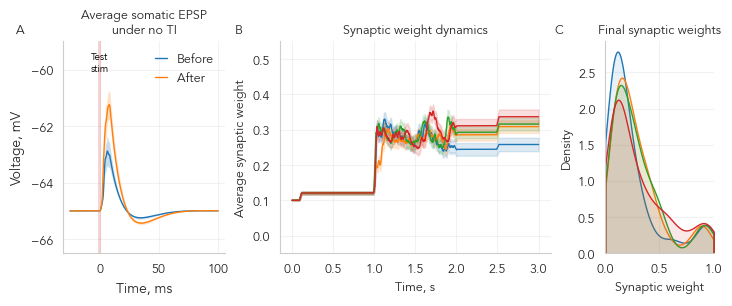

In [137]:
fig = plt.figure(figsize = (8.4, 2.75))

outer_gs = gridspec.GridSpec(1, 1, height_ratios = [1])

# A panel - neuron with synapses marked
# B panel - EPSP

inner_gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec = outer_gs[0], wspace = 0.3, width_ratios = [1.2, 2, 0.8])
ax = fig.add_subplot(inner_gs[0, 0])

epsp_before = []
epsp_after = []

time = []

time_before = 25
time_after = 100

for idx in idxs:
    voltage = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/noTI_0.1/voltage.csv")

    time_epsp_before = np.logical_and(voltage.Time > test_stimulus_1 - time_before, voltage.Time < test_stimulus_1 + time_after)
    epsp_before_idx = np.array(voltage.Voltage[time_epsp_before].tolist())
    epsp_before.append(epsp_before_idx)

    time_epsp_after = np.logical_and(voltage.Time > test_stimulus_2 - time_before, voltage.Time < test_stimulus_2 + time_after)
    epsp_after_idx = np.array(voltage.Voltage[time_epsp_after].tolist())
    epsp_after.append(epsp_after_idx)

    time = np.array((voltage.Time[time_epsp_before] - test_stimulus_1).tolist())
    time, epsp_before_idx, epsp_after_idx = match_array_size(time, epsp_before_idx, epsp_after_idx)

epsp_before = np.array(epsp_before).T
epsp_after = np.array(epsp_after).T

time, epsp_before, epsp_after = match_array_size(time, epsp_before, epsp_after)

mean = epsp_before.mean(axis = 1)
error = epsp_before.std(axis = 1)  / np.sqrt(epsp_before.shape[1])

max_at = np.argmax(mean)
std = epsp_before.std(axis = 1)
print(f"EPSP before: {round(mean[max_at] - mean[0], 2)}")
print(f"STD: {round(std[max_at], 2)}")

plt.plot(
    time,
    mean,
    linewidth = 1,
    label = "Before"
)
plt.fill_between(
    time, mean - error, mean + error,
    alpha = 0.25
)

mean = epsp_after.mean(axis = 1)
error = epsp_after.std(axis = 1) / np.sqrt(epsp_after.shape[1])

max_at = np.argmax(mean)
std = epsp_after.std(axis = 1)
print(f"EPSP after: {round(mean[max_at] - mean[0], 2)}")
print(f"STD: {round(std[max_at], 2)}")

ax.plot(
    time,
    mean,
    linewidth = 1,
    label = "After"
)
ax.fill_between(
    time, mean - error, mean + error,
    alpha = 0.25
)

ax.set_xlabel("Time, ms", fontsize = 10)
ax.set_ylabel("Voltage, mV", fontsize = 10)
ax.set_ylim(-66.5, -59)
ax.set_yticks(np.arange(-66, -59, 2))

ax.axvspan(
    -1,
    1,
    alpha = 0.2,
    color = "tab:red",
    zorder = 1,
    linewidth = 0
)

ax.text(
    0, -59.75,
    "Test\nstim",
    color = "black",
    va = "center",
    ha = "center",
    fontsize = 7
)

ax.grid(True, alpha = 0.25)

ax.legend(frameon = False, loc = "upper right", ncol = 1, fontsize = 9, handlelength = 1)

ax.set_title("Average somatic EPSP\nunder no TI")

####

ax = fig.add_subplot(inner_gs[0, 1])

plot_weights(weights_no_ti, time_no_ti, label = "No TI", color = colors["No TI"], ax = ax)
plot_weights(weights_5, time_5, label = "5 Hz TI", color = colors["5 Hz TI"], ax = ax)
plot_weights(weights_130, time_130, label = "130 Hz TI", color = colors["130 Hz TI"], ax = ax)
plot_weights(weights_0, time_0, label = "0 Hz TI", color = colors["0 Hz TI"], ax = ax)

ax.set_ylim(-0.05, 0.55)
ax.set_ylabel("Average synaptic weight")
ax.set_yticks(np.arange(0, 0.6, 0.1))

ax.set_xlabel("Time, s")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: x / 1000))

ax.grid(alpha = 0.25)
ax.set_title("Synaptic weight dynamics")

######

ax = fig.add_subplot(inner_gs[0, 2])

for condition in final_weights.keys():
    sns.kdeplot(
        final_weights[condition],
        bw_adjust = 1,
        ax = ax,
        clip = (0, 1),
        label = condition,
        fill = True,
        alpha = 0.1
    )

ax.set_xlim(0, 1)
ax.set_xlabel("Synaptic weight")

ax.set_title("Final synaptic weights")

ax.grid(alpha = 0.25)
sns.despine(top = True, right = True)

fig.text(0.07, 0.91, "A", fontsize = 9)
fig.text(0.33, 0.91, "B", fontsize = 9)
fig.text(0.71, 0.91, "C", fontsize = 9)

plt.savefig("results_3_new.png", dpi = 500, bbox_inches = "tight")

In [138]:
def generate_ltp_spike_times():
    """Generate Poisson-distributed spike times."""
    spikes = []
    t = test_stimulus_1 + int(1000 / ltp_frequency)
    spikes.append(t)

    t = ltp_start
    while t <= ltp_start + ltp_duration:
        spikes.append(t)
        isi = int(1000 / ltp_frequency)
        t += isi

    t = test_stimulus_2
    spikes.append(t)

    return spikes

In [139]:
spikes = generate_ltp_spike_times()

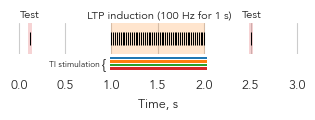

In [152]:
fig = plt.figure(figsize = (8.4, 6))

outer_gs = gridspec.GridSpec(3, 1, height_ratios = [1, 0.21, 1])
inner_gs_1 = gridspec.GridSpecFromSubplotSpec(9, 6, subplot_spec = outer_gs[0], width_ratios = [1, -0.1, 1, 1, 0.25, 1], height_ratios = [0.6, 0.025, 0.05, 0.05, 0.05, 0.05, 0.9, 0.9, 0.9], hspace = 0.05)

ax_a1 = fig.add_subplot(inner_gs_1[0, 2:4])

ax = ax_a1

ax.axvspan(
    test_stimulus_1 - 1,
    test_stimulus_1 + 44,
    alpha = 0.2,
    color = "tab:red",
    label = "Test stimulus",
    zorder = 1,
    linewidth = 0
)

ax.axvspan(
    test_stimulus_2 - 20,
    test_stimulus_2 + 25,
    alpha = 0.2,
    color = "tab:red",
    zorder = 1,
    linewidth = 0
)

ax.axvspan(
    ltp_start - 10,
    ltp_start + ltp_duration + 10,
    alpha = 0.2,
    color = "tab:orange",
    label = "LTP induction: (100 Hz for 1 s)",
    zorder = 1,
    linewidth = 0
)

ax.eventplot(
    spikes,
    lineoffsets = 1,
    linelengths = 1.25,
    colors = "black",
    linewidths = 0.75,
    zorder = 3,
    rasterized = True
)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.set_ylim(-0.5, 2.5)

ax.set_xlim(-50, 3050)
ax.set_xticks(np.arange(0, 3200, 500))
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.set_yticks([])
ax.set_xticklabels([])
ax.spines["bottom"].set_visible(False)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: x / 1000))

fig.text(0.32, 0.89, "Test", fontsize = 8)
fig.text(0.40, 0.89, "LTP induction (100 Hz for 1 s)", fontsize = 8)
fig.text(0.585, 0.89, "Test", fontsize = 8)

################## The BLUE line

ax = fig.add_subplot(inner_gs_1[2, 2:4])

ax.axvspan(
    ltp_start - 20,
    ltp_start + ltp_duration + 25,
    color = "tab:blue",
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(-50, 3050)
ax.set_xticks(np.arange(0, 3200, 500))
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

################## The ORANGE line

ax = fig.add_subplot(inner_gs_1[3, 2:4])

ax.axvspan(
    ltp_start - 20,
    ltp_start + ltp_duration + 25,
    color = "tab:orange",
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(-50, 3050)
ax.set_xticks(np.arange(0, 3200, 500))
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# The GREEN line

ax = fig.add_subplot(inner_gs_1[4, 2:4])

ax.axvspan(
    ltp_start - 20,
    ltp_start + ltp_duration + 25,
    color = "tab:green",
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(-50, 3050)
ax.set_xticks(np.arange(0, 3200, 500))
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# The RED line

ax = fig.add_subplot(inner_gs_1[5, 2:4])

ax.axvspan(
    ltp_start - 20,
    ltp_start + ltp_duration + 25,
    color = "tab:red",
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(-50, 3050)
ax.set_xticks(np.arange(0, 3200, 500))
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: x / 1000))

ax.set_xlabel("Time, s")

fig.text(0.385, 0.81235, "TI stimulation", fontsize = 6, va = "center", ha = "center")
fig.text(0.42, 0.81235, "{", fontsize = 10, va = "center", ha = "center")

plt.savefig("results_3_new_2.png", dpi = 500, bbox_inches = "tight")

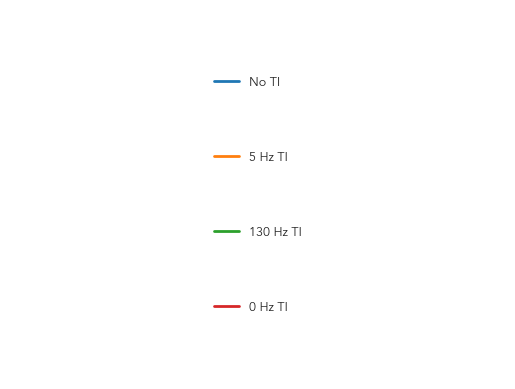

In [149]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots()

# Dummy handles for the legend
handles = [
    Line2D([0], [0], color="tab:blue", lw=2, label="No TI"),
    Line2D([0], [0], color="tab:orange", lw=2, label="5 Hz TI"),
    Line2D([0], [0], color="tab:green", lw=2, label="130 Hz TI"),
    Line2D([0], [0], color="tab:red", lw=2, label="0 Hz TI")
]

# Hide the axes
ax.axis("off")

# Add only the legend
legend = ax.legend(handles=handles, frameon=False, loc="center", labelspacing = 5)

# Save or show
plt.savefig("legend_only.png", bbox_inches="tight", dpi=300)
plt.show()